### Import danych

In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
import textwrap

In [2]:
df_waw = pd.read_csv("data/warszawa-gus-bdl.csv", delimiter=";")
df_krk = pd.read_csv("data/krakow-gus-bdl.csv", delimiter=";")

In [3]:
df_waw.columns

Index(['Kategoria', 'Grupa', 'Podgrupa (wymiary)', 'Wymiar 1', 'Wymiar 2',
       'Wymiar 3', 'Wymiar 4', 'Wymiar 5', 'Jednostka miary', '2016', '2017',
       '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025',
       'Unnamed: 19'],
      dtype='str')

In [4]:
# print all unique categories and it's groups and it's Podgrupa (wymiary)

pg_count_waw = df_waw['Podgrupa (wymiary)'].nunique()
pg_count_krk = df_krk['Podgrupa (wymiary)'].nunique()
print(f"Number of unique Podgrupa (wymiary): {pg_count_waw} (Warszawa), {pg_count_krk} (Kraków)")

mutual_pg = set(df_waw['Podgrupa (wymiary)']).intersection(set(df_krk['Podgrupa (wymiary)']))
print(f"Number of mutual Podgrupa (wymiary): {len(mutual_pg)}")
unique_pg_waw = set(df_waw['Podgrupa (wymiary)']).difference(set(df_krk['Podgrupa (wymiary)']))
print(f"Number of unique Podgrupa (wymiary) in Warszawa: {len(unique_pg_waw)}")
print(f"Unique Podgrupa (wymiary) in Warszawa: {unique_pg_waw}")
unique_pg_krk = set(df_krk['Podgrupa (wymiary)']).difference(set(df_waw['Podgrupa (wymiary)']))
print(f"Number of unique Podgrupa (wymiary) in Kraków: {len(unique_pg_krk)}")
print(f"Unique Podgrupa (wymiary) in Kraków: {unique_pg_krk}")

for cat in df_waw['Kategoria'].unique():
    print(f"Kategoria: {cat}")
    for group in df_waw[df_waw['Kategoria'] == cat]['Grupa'].unique():
        print(f"  Grupa: {group}")
        for podgrupa in df_waw[(df_waw['Kategoria'] == cat) & (df_waw['Grupa'] == group)]['Podgrupa (wymiary)'].unique():
            print(f"    Podgrupa: {podgrupa}")
            for w in df_waw[(df_waw['Kategoria'] == cat) & (df_waw['Grupa'] == group) & (df_waw['Podgrupa (wymiary)'] == podgrupa)]['Wymiar 1'].unique():
                print(f"      Wymiar: {w}")

Number of unique Podgrupa (wymiary): 232 (Warszawa), 231 (Kraków)
Number of mutual Podgrupa (wymiary): 226
Number of unique Podgrupa (wymiary) in Warszawa: 6
Unique Podgrupa (wymiary) in Warszawa: {'Przewozy ładunków morską flotą transportową według relacji (Wymiary: Przewozy ładunków)', 'Mieszkania w budynkach (gminnych) zwrócone dawnym indywidualnym właścicielom bądź spadkobiercom (Wymiary: Budynki/mieszkania/powierzchnia)', 'Przewozy ładunków morską flotą transportową według rodzajów żeglugi i zasięgu pływania (Wymiary: Żegluga; Zasięg)', 'Osady dotychczas składowane (nagromadzone) na terenie oczyszczalni i wykorzystane z dotychczas składowanych (Wymiary: Osady)', 'Zasoby mieszkaniowe gmin (komunalne) wynajmowane od innych podmiotów (Wymiary: Rodzaje zasobów mieszkaniowych; Zasoby mieszkaniowe)', 'Morska flota transportowa (Wymiary: Liczba statków / nośność; Rodzaje statków)'}
Number of unique Podgrupa (wymiary) in Kraków: 5
Unique Podgrupa (wymiary) in Kraków: {'Dział 756 - Dochody

In [5]:
def get_series(df, cat, group, subgroup, w1='', w2='', w3='', w4='', w5='') -> pd.Series:
    mask = (
        (df['Kategoria'] == cat) &
        (df['Grupa'] == group) &
        (df['Podgrupa (wymiary)'] == subgroup) &
        (df['Wymiar 1'].fillna('') == w1) &
        (df['Wymiar 2'].fillna('') == w2) &
        (df['Wymiar 3'].fillna('') == w3) &
        (df['Wymiar 4'].fillna('') == w4) &
        (df['Wymiar 5'].fillna('') == w5)
    )
    row = df[mask]
    
    if row.empty:
        print("No matching row found.")
        
    years = [str(yr) for yr in range(2016, 2026)]
    series = row.iloc[0][years].str.replace(',', '.').astype(float)
    
    return series

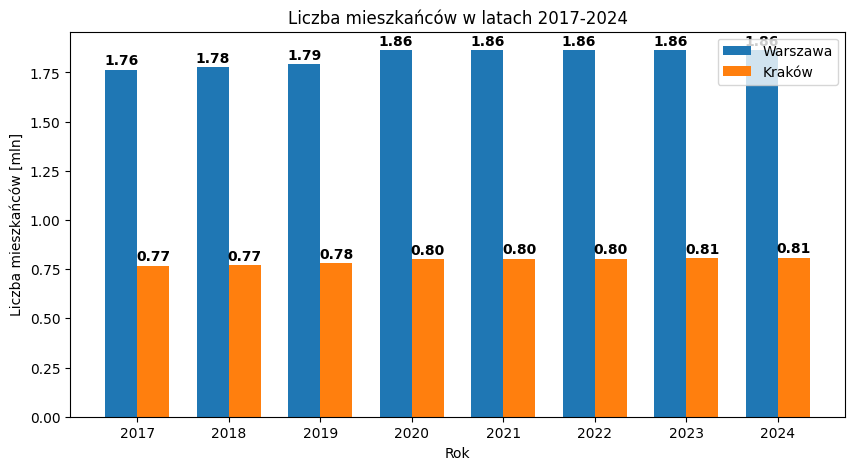

In [6]:
people_loc = ["LUDNOŚĆ","STAN LUDNOŚCI","Ludność wg grup wieku i płci (Wymiary: Wiek; Płeć)","ogółem","ogółem"]
people_waw = get_series(df_waw, *people_loc)[1:].dropna()
people_krk = get_series(df_krk, *people_loc)[1:].dropna()

bar_width = 0.35
index = np.arange(len(people_waw))

plt.figure(figsize=(10, 5))
plt.bar(index, people_waw.values / 1e6, bar_width, label='Warszawa')
plt.bar(index + bar_width, people_krk.values / 1e6, bar_width, label='Kraków')
plt.xticks(index + bar_width / 2, people_waw.index)
# add bold number labels stick to top of bars
for i in range(len(people_waw)):
    plt.text(index[i], people_waw.values[i] / 1e6 + 0.01, f"{people_waw.values[i]/1e6:,.2f}", ha='center', va='bottom', fontweight='bold')
    plt.text(index[i] + bar_width, people_krk.values[i] / 1e6 + 0.01, f"{people_krk.values[i]/1e6:,.2f}", ha='center', va='bottom', fontweight='bold')
plt.title('Liczba mieszkańców w latach 2017-2024')
plt.ylabel('Liczba mieszkańców [mln]')
plt.xlabel('Rok')
plt.legend()
plt.savefig('img/population_comparison.png')

### Wskaźnik jakosci życia

In [7]:
waw_person_data = {}
krk_person_data = {}

In [8]:
months = ['styczeń', 'luty', 'marzec', 'kwiecień', 'maj', 'czerwiec', 'lipiec', 'sierpień', 'wrzesień', 'październik', 'listopad', 'grudzień']
median_salaries_waw_24 = 0
median_salaries_krk_24 = 0
for month in months:
    salaries_loc = ["WYNAGRODZENIA I ŚWIADCZENIA SPOŁECZNE","WYNAGRODZENIA","Mediana wynagrodzeń miesięcznych brutto według badania Rozkład wynagrodzeń w gospodarce narodowej (Wymiary: Miesiące; Zakres przedmiotowy; Płeć)", month, "wg miejsca zamieszkania", "ogółem"]
    median_salaries_waw_24 += get_series(df_waw, *salaries_loc).values[-2] / 12 # 2024
    median_salaries_krk_24 += get_series(df_krk, *salaries_loc).values[-2] / 12 # 2024

waw_person_data['Mediana wynagrodzeń miesięcznych brutto [zl]'] = [round(median_salaries_waw_24, 2), True]
krk_person_data['Mediana wynagrodzeń miesięcznych brutto [zl]'] = [round(median_salaries_krk_24, 2), True]
print(f"Średnia mediana wynagrodzeń miesięcznych brutto w 2024 roku: {median_salaries_waw_24:.2f} PLN (Warszawa), {median_salaries_krk_24:.2f} PLN (Kraków)")

Średnia mediana wynagrodzeń miesięcznych brutto w 2024 roku: 8958.06 PLN (Warszawa), 7985.85 PLN (Kraków)


In [ ]:
m2_loc = ["GOSPODARKA MIESZKANIOWA I KOMUNALNA", "ZASOBY MIESZKANIOWE", "Zasoby mieszkaniowe - wskaźniki (Wymiary: Wskaźniki)", "przeciętna powierzchnia użytkowa mieszkania na 1 osobę"]
waw_person_data['Przeciętna powierzchnia użytkowa mieszkania na 1 osobę [m2]'] = [get_series(df_waw, *m2_loc).values[-2], True]
krk_person_data['Przeciętna powierzchnia użytkowa mieszkania na 1 osobę [m2]'] = [get_series(df_krk, *m2_loc).values[-2], True]

unemployment_loc = ["RYNEK PRACY","BEZROBOCIE REJESTROWANE","Udział bezrobotnych zarejestrowanych w liczbie ludności w wieku produkcyjnym wg płci (Wymiary: Płeć)","ogółem"]
waw_person_data['Udział bezrobotnych w wieku produkcyjnym [%]'] = [get_series(df_waw, *unemployment_loc).values[-2], False]
krk_person_data['Udział bezrobotnych w wieku produkcyjnym [%]'] = [get_series(df_krk, *unemployment_loc).values[-2], False]

nursery_loc = ["OCHRONA ZDROWIA, OPIEKA SPOŁECZNA I ŚWIADCZENIA NA RZECZ RODZINY", "OPIEKA NAD DZIEĆMI W WIEKU DO LAT 3.  ŻŁOBKI", "Żłobki i kluby dziecięce - wskaźniki (Wymiary: Wskaźniki)", "dzieci w żłobkach i klubach dziecięcych na 1000 dzieci w wieku do lat 3"]
waw_person_data['Dzieci w żłobkach na 1000 dzieci do lat 3 [os.]'] = [get_series(df_waw, *nursery_loc).values[-2], True]
krk_person_data['Dzieci w żłobkach na 1000 dzieci do lat 3 [os.]'] = [get_series(df_krk, *nursery_loc).values[-2], True]

pharmacy_loc = ["OCHRONA ZDROWIA, OPIEKA SPOŁECZNA I ŚWIADCZENIA NA RZECZ RODZINY", "APTEKI I PUNKTY APTECZNE", "Apteki ogólnodostępne - wskaźniki (Wymiary: Wskaźniki)", "ludność na aptekę ogólnodostępną"]
waw_person_data['Ludność na aptekę ogólnodostępną [os.]'] = [get_series(df_waw, *pharmacy_loc).values[-2], False]
krk_person_data['Ludność na aptekę ogólnodostępną [os.]'] = [get_series(df_krk, *pharmacy_loc).values[-2], False]

supermarket_loc = ["HANDEL I GASTRONOMIA", "SKLEPY I STACJE PALIW", "Sklepy wg form organizacyjnych (Wymiary: Formy organizacyjne)", "supermarkety"]
waw_person_data['Ludność na supermarket [os.]'] = [(people_waw['2024']/get_series(df_waw, *supermarket_loc)).round(2).values[-2], False]
krk_person_data['Ludność na supermarket [os.]'] = [(people_krk['2024']/get_series(df_krk, *supermarket_loc)).round(2).values[-2], False]

green_areas_loc = ["STAN I OCHRONA ŚRODOWISKA", "TERENY ZIELENI", "Tereny zieleni - wskaźniki (Wymiary: Wskaźniki)", "powierzchnia gminnych terenów zieleni na 1 mieszkańca"]
waw_person_data['Powierzchnia gminnych terenów zieleni na 1 mieszkańca [m2]'] = [get_series(df_waw, *green_areas_loc).values[-2], True]
krk_person_data['Powierzchnia gminnych terenów zieleni na 1 mieszkańca [m2]'] = [get_series(df_krk, *green_areas_loc).values[-2], True]

bike_bus_lanes_loc = ["TRANSPORT I ŁĄCZNOŚĆ", "DROGI DLA ROWERÓW", "Długość dróg dla rowerów (Wymiary: Drogi dla rowerów i buspasy)", "drogi dla rowerów na 10 tys. km2"]
waw_person_data['Drogi dla rowerów na km2 [km]'] = [round(get_series(df_waw, *bike_bus_lanes_loc).values[-2]/10000, 2), True]
krk_person_data['Drogi dla rowerów na km2 [km]'] = [round(get_series(df_krk, *bike_bus_lanes_loc).values[-2]/10000, 2), True]

road_accidents_loc = ["TRANSPORT I ŁĄCZNOŚĆ", "WYPADKI DROGOWE", "Wypadki drogowe i ich ofiary - wskaźniki (Wymiary: Wskaźniki)", "wypadki drogowe na 1000 ludności"]
waw_person_data['Wypadki drogowe na 1000 ludności [l.]'] = [get_series(df_waw, *road_accidents_loc).values[-2], False]
krk_person_data['Wypadki drogowe na 1000 ludności [l.]'] = [get_series(df_krk, *road_accidents_loc).values[-2], False]

public_transport_loc = ["TRANSPORT I ŁĄCZNOŚĆ", "KOMUNIKACJA MIEJSKA", "Czynne przystanki (Wymiary: Przystanki,  Wyszczególnienie)", "ogółem (przystanki autobusowe (z trolejbusowymi) i tramwajowe, przystanki wspólne dla tramwajów i autobusów)", "ogółem"]
waw_person_data['Czynne przystanki komunikacji miejskiej na 1 km2 [l.]']

In [10]:
print("Dane dla Warszawy:")
for key, value in waw_person_data.items():
    print(f"{key}: {value}")

print("\nDane dla Krakowa:")
for key, value in krk_person_data.items():
    print(f"{key}: {value}")

Dane dla Warszawy:
Mediana wynagrodzeń miesięcznych brutto [zl]: [np.float64(8958.06), True]
Przeciętna powierzchnia użytkowa mieszkania na 1 osobę [m2]: [np.float64(34.5), True]
Udział bezrobotnych w wieku produkcyjnym [%]: [np.float64(1.7), False]
Dzieci w żłobkach na 1000 dzieci do lat 3 [os.]: [np.float64(323.0), True]
Ludność na aptekę ogólnodostępną [os.]: [np.float64(3192.0), False]
Ludność na supermarket [os.]: [np.float64(5481.9), False]
Powierzchnia gminnych terenów zieleni na 1 mieszkańca [m2]: [np.float64(7.8), True]
Drogi dla rowerów na km2 [km]: [np.float64(1.57), True]
Wypadki drogowe na 1000 ludności [l.]: [np.float64(0.37), False]

Dane dla Krakowa:
Mediana wynagrodzeń miesięcznych brutto [zl]: [np.float64(7985.86), True]
Przeciętna powierzchnia użytkowa mieszkania na 1 osobę [m2]: [np.float64(33.4), True]
Udział bezrobotnych w wieku produkcyjnym [%]: [np.float64(2.2), False]
Dzieci w żłobkach na 1000 dzieci do lat 3 [os.]: [np.float64(395.7), True]
Ludność na aptekę o

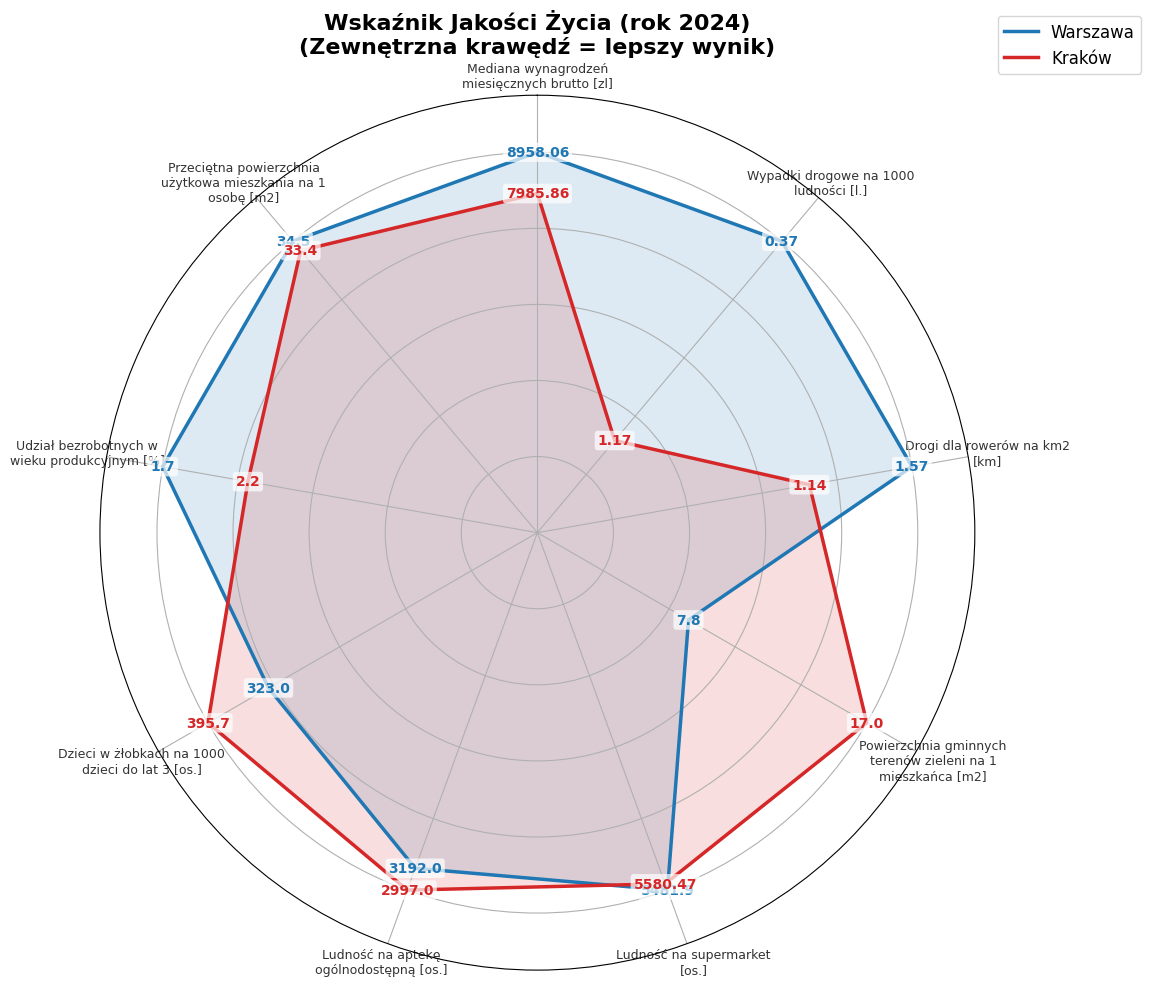

In [11]:
categories = list(waw_person_data.keys())
N = len(categories)
wrapped_labels = [textwrap.fill(cat, width=25) for cat in categories]

# Data normalization for radar chart
waw_scores = []
krk_scores = []

for cat in categories:
    val_waw, more_better = waw_person_data[cat]
    val_krk, _ = krk_person_data[cat]
    
    if more_better:
        max_val = max(val_waw, val_krk)
        waw_scores.append((val_waw / max_val) * 100)
        krk_scores.append((val_krk / max_val) * 100)
    else:
        min_val = min(val_waw, val_krk)
        waw_scores.append((min_val / val_waw) * 100)
        krk_scores.append((min_val / val_krk) * 100)

angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]
waw_scores += waw_scores[:1]
krk_scores += krk_scores[:1]

fig, ax = plt.subplots(figsize=(12, 10), subplot_kw=dict(polar=True))
ax.set_theta_offset(np.pi / 2) 

plt.xticks(angles[:-1], wrapped_labels, color='#333333', size=9)

ax.set_yticklabels([])
plt.ylim(0, 115)

color_waw = '#1f77b4'
color_krk = '#d62728'

ax.plot(angles, waw_scores, linewidth=2.5, linestyle='solid', label='Warszawa', color=color_waw)
ax.fill(angles, waw_scores, color_waw, alpha=0.15)

ax.plot(angles, krk_scores, linewidth=2.5, linestyle='solid', label='Kraków', color=color_krk)
ax.fill(angles, krk_scores, color_krk, alpha=0.15)

for i in range(N):
    angle_rad = angles[i]
    
    val_waw = waw_person_data[categories[i]][0]
    val_krk = krk_person_data[categories[i]][0]
    
    bbox_props = dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7)
    
    ax.text(angle_rad, waw_scores[i], f"{val_waw}", 
            color=color_waw, size=10, weight='bold',
            ha='center', va='center', bbox=bbox_props)
    
    ax.text(angle_rad, krk_scores[i], f"{val_krk}", 
            color=color_krk, size=10, weight='bold',
            ha='center', va='center', bbox=bbox_props)

plt.title('Wskaźnik Jakości Życia (rok 2024)\n(Zewnętrzna krawędź = lepszy wynik)', 
          size=16, weight='bold', pad=30)
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1), fontsize=12)

fig.tight_layout()
plt.savefig('img/quality_indicator.png', dpi=300)
plt.show()

### Dbałość mieszkańców o środowisko

In [12]:

years = [2016, 2018, 2020, 2022, 2024]

metrics = {
    'Zużycie wody [m³/os]': {
        'WAW': [36, 35, 34, 33, 33],
        'KRK': [31, 30, 29, 28, 28]
    },
    'Odpady zmieszane [kg/os]': {
        'WAW': [220, 210, 200, 190, 180],
        'KRK': [210, 205, 200, 195, 190]
    },
    'Energia w gosp. dom. [kWh/os]': {
        'WAW': [850, 840, 820, 810, 800],
        'KRK': [880, 870, 860, 850, 840]
    },
    'Ścieki odprowadzone [m³/os]': {
        'WAW': [32, 31, 30, 29, 28],
        'KRK': [28, 27, 27, 26, 26]
    }
}



In [13]:
WARSAW_AREA = 517.24
KRAKOW_AREA = 327.00

In [14]:
metrics = {}
water_usage_loc = ["GOSPODARKA MIESZKANIOWA I KOMUNALNA", "URZĄDZENIA SIECIOWE", "Zużycie wody, energii elektrycznej oraz gazu w gospodarstwach domowych (Wymiary: Lokalizacje; Woda/energia elektryczna/gaz; Wskaźniki)", "ogółem", "woda z wodociągów", "na 1 mieszkańca"]
metrics['Zużycie wody [m³/os]'] = {
    'WAW': get_series(df_waw, *water_usage_loc).dropna(),
    'KRK': get_series(df_krk, *water_usage_loc).dropna(),
    "Positive": False
}
gas_usage_loc = ["GOSPODARKA MIESZKANIOWA I KOMUNALNA", "URZĄDZENIA SIECIOWE", "Zużycie wody, energii elektrycznej oraz gazu w gospodarstwach domowych (Wymiary: Lokalizacje; Woda/energia elektryczna/gaz; Wskaźniki)", "ogółem", "gaz z sieci w kWh", "na 1 mieszkańca"]
metrics['Zużycie energii w gosp. dom. [kWh/os]'] = {
    'WAW': get_series(df_waw, *gas_usage_loc).dropna(),
    'KRK': get_series(df_krk, *gas_usage_loc).dropna(),
    "Positive": False
}
electricity_usage_loc = ["GOSPODARKA MIESZKANIOWA I KOMUNALNA", "URZĄDZENIA SIECIOWE", "Zużycie wody, energii elektrycznej oraz gazu w gospodarstwach domowych (Wymiary: Lokalizacje; Woda/energia elektryczna/gaz; Wskaźniki)", "w miastach", "energia elektryczna w miastach", "na 1 mieszkańca"]
metrics['Zużycie prądu w gosp. dom. [kWh/os]'] = {
    'WAW': get_series(df_waw, *electricity_usage_loc).dropna(),
    'KRK': get_series(df_krk, *electricity_usage_loc).dropna(),
    "Positive": False
}
new_trees_loc = ["STAN I OCHRONA ŚRODOWISKA", "TERENY ZIELENI", "Nasadzenia i ubytki wg lokalizacji w gminach (Wymiary: Prace leśne; Drzewa i krzewy; Lokalizacje)", "nasadzenia", "drzewa", "ogółem (w miastach i na wsi)"]
metrics['Skumulowana liczba nowych drzew na 1km2 [szt.]'] = {
    'WAW': get_series(df_waw, *new_trees_loc).dropna().div(WARSAW_AREA).round(2),
    'KRK': get_series(df_krk, *new_trees_loc).dropna().div(KRAKOW_AREA).round(2),
    "Positive": True
}
new_bushes_loc = ["STAN I OCHRONA ŚRODOWISKA", "TERENY ZIELENI", "Nasadzenia i ubytki wg lokalizacji w gminach (Wymiary: Prace leśne; Drzewa i krzewy; Lokalizacje)", "nasadzenia", "krzewy", "ogółem (w miastach i na wsi)"]
metrics['Skumulowana liczba nowych krzewów na 1km2 [szt.]'] = {
    'WAW': get_series(df_waw, *new_bushes_loc).dropna().div(WARSAW_AREA).round(2),
    'KRK': get_series(df_krk, *new_bushes_loc).dropna().div(KRAKOW_AREA).round(2),
    "Positive": True
}
green_areas_loc = ["STAN I OCHRONA ŚRODOWISKA", "TERENY ZIELENI", "Tereny zieleni - wskaźniki (Wymiary: Wskaźniki)", "powierzchnia gminnych terenów zieleni na 1 mieszkańca"]
metrics['Powierzchnia gminnych terenów zieleni na 1 mieszkańca [m2]'] = {
    'WAW': get_series(df_waw, *green_areas_loc).dropna(),
    'KRK': get_series(df_krk, *green_areas_loc).dropna(),
    'Positive': True
}
seletive_rubbish_loc = ["STAN I OCHRONA ŚRODOWISKA", "ODPADY KOMUNALNE", "Odpady zebrane selektywnie w relacji do ogółu odpadów (Wymiary: Ogółem)", "z gospodarstw domowych"]
metrics['Procent odpadów zebranych selektywnie [%]'] = {
    'WAW': get_series(df_waw, *seletive_rubbish_loc).dropna(),
    'KRK': get_series(df_krk, *seletive_rubbish_loc).dropna(),
    'Positive': True
}
communal_rubbish_created_loc = ["STAN I OCHRONA ŚRODOWISKA", "ODPADY KOMUNALNE", "Odpady komunalne wytworzone w ciągu roku (Wymiary: Pochodzenie odpadów)", "z gospodarstw domowych"]
metrics['Odpady komunalne z gospodarstw domowych na 1 mieszkańca [kg]'] = {
    'WAW': get_series(df_waw, *communal_rubbish_created_loc).dropna().div(people_waw / 1000).round(2),
    'KRK': get_series(df_krk, *communal_rubbish_created_loc).dropna().div(people_krk / 1000).round(2),
    'Positive': False
}
law_protected_areas_loc = ["STAN I OCHRONA ŚRODOWISKA", "OCHRONA PRZYRODY I RÓŻNORODNOŚCI BIOLOGICZNEJ", "Obszary prawnie chronione - wskaźniki (Wymiary: Wskaźniki)", "udział obszarów prawnie chronionych w powierzchni ogółem"]
metrics['Obszary zielone chronione prawem względem powierzchni ogółem [%]'] = {
    'WAW': get_series(df_waw, *law_protected_areas_loc).dropna(),
    'KRK': get_series(df_krk, *law_protected_areas_loc).dropna(),
    'Positive': True
}
collected_sewage_loc = ["STAN I OCHRONA ŚRODOWISKA", "OCZYSZCZANIE ŚCIEKÓW KOMUNALNYCH", "Ścieki oczyszczane w ciągu roku (Wymiary: Rodzaje ścieków)", "odprowadzone ogółem"]
filtered_collected_sewage_loc = ["STAN I OCHRONA ŚRODOWISKA", "OCZYSZCZANIE ŚCIEKÓW KOMUNALNYCH", "Ścieki oczyszczane w ciągu roku (Wymiary: Rodzaje ścieków)", "oczyszczane razem"]
metrics['Udział ścieków oczyszczanych w stosunku do odprowadzonych [%]'] = {
    'WAW': get_series(df_waw, *filtered_collected_sewage_loc).dropna().div(get_series(df_waw, *collected_sewage_loc).dropna()).mul(100).round(2),
    'KRK': get_series(df_krk, *filtered_collected_sewage_loc).dropna().div(get_series(df_krk, *collected_sewage_loc).dropna()).mul(100).round(2),
    'Positive': True
}


In [15]:
# shorten data to years 2017-2024 (from mixed 2016/17-2024)
allowed_years = np.arange(2017, 2025).astype(str)
for key in metrics.keys():
    metrics[key]['WAW'] = metrics[key]['WAW'][metrics[key]['WAW'].index.isin(allowed_years)]
    metrics[key]['KRK'] = metrics[key]['KRK'][metrics[key]['KRK'].index.isin(allowed_years)]

In [16]:
for name, values in metrics.items():
    print(f"Metric: {name}, len: {len(values['WAW'])}, {len(values['KRK'])}")
    print(f"WAW: {values['WAW'].index}")
    print(f"KRK: {values['KRK'].index}")

Metric: Zużycie wody [m³/os], len: 8, 8
WAW: Index(['2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024'], dtype='str')
KRK: Index(['2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024'], dtype='str')
Metric: Zużycie energii w gosp. dom. [kWh/os], len: 8, 8
WAW: Index(['2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024'], dtype='str')
KRK: Index(['2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024'], dtype='str')
Metric: Zużycie prądu w gosp. dom. [kWh/os], len: 8, 8
WAW: Index(['2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024'], dtype='str')
KRK: Index(['2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024'], dtype='str')
Metric: Skumulowana liczba nowych drzew na 1km2 [szt.], len: 8, 8
WAW: Index(['2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024'], dtype='str')
KRK: Index(['2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024'], dtype='str')
Metric: Skumulowana liczba nowych krzewów na 1km2 [szt.], len:

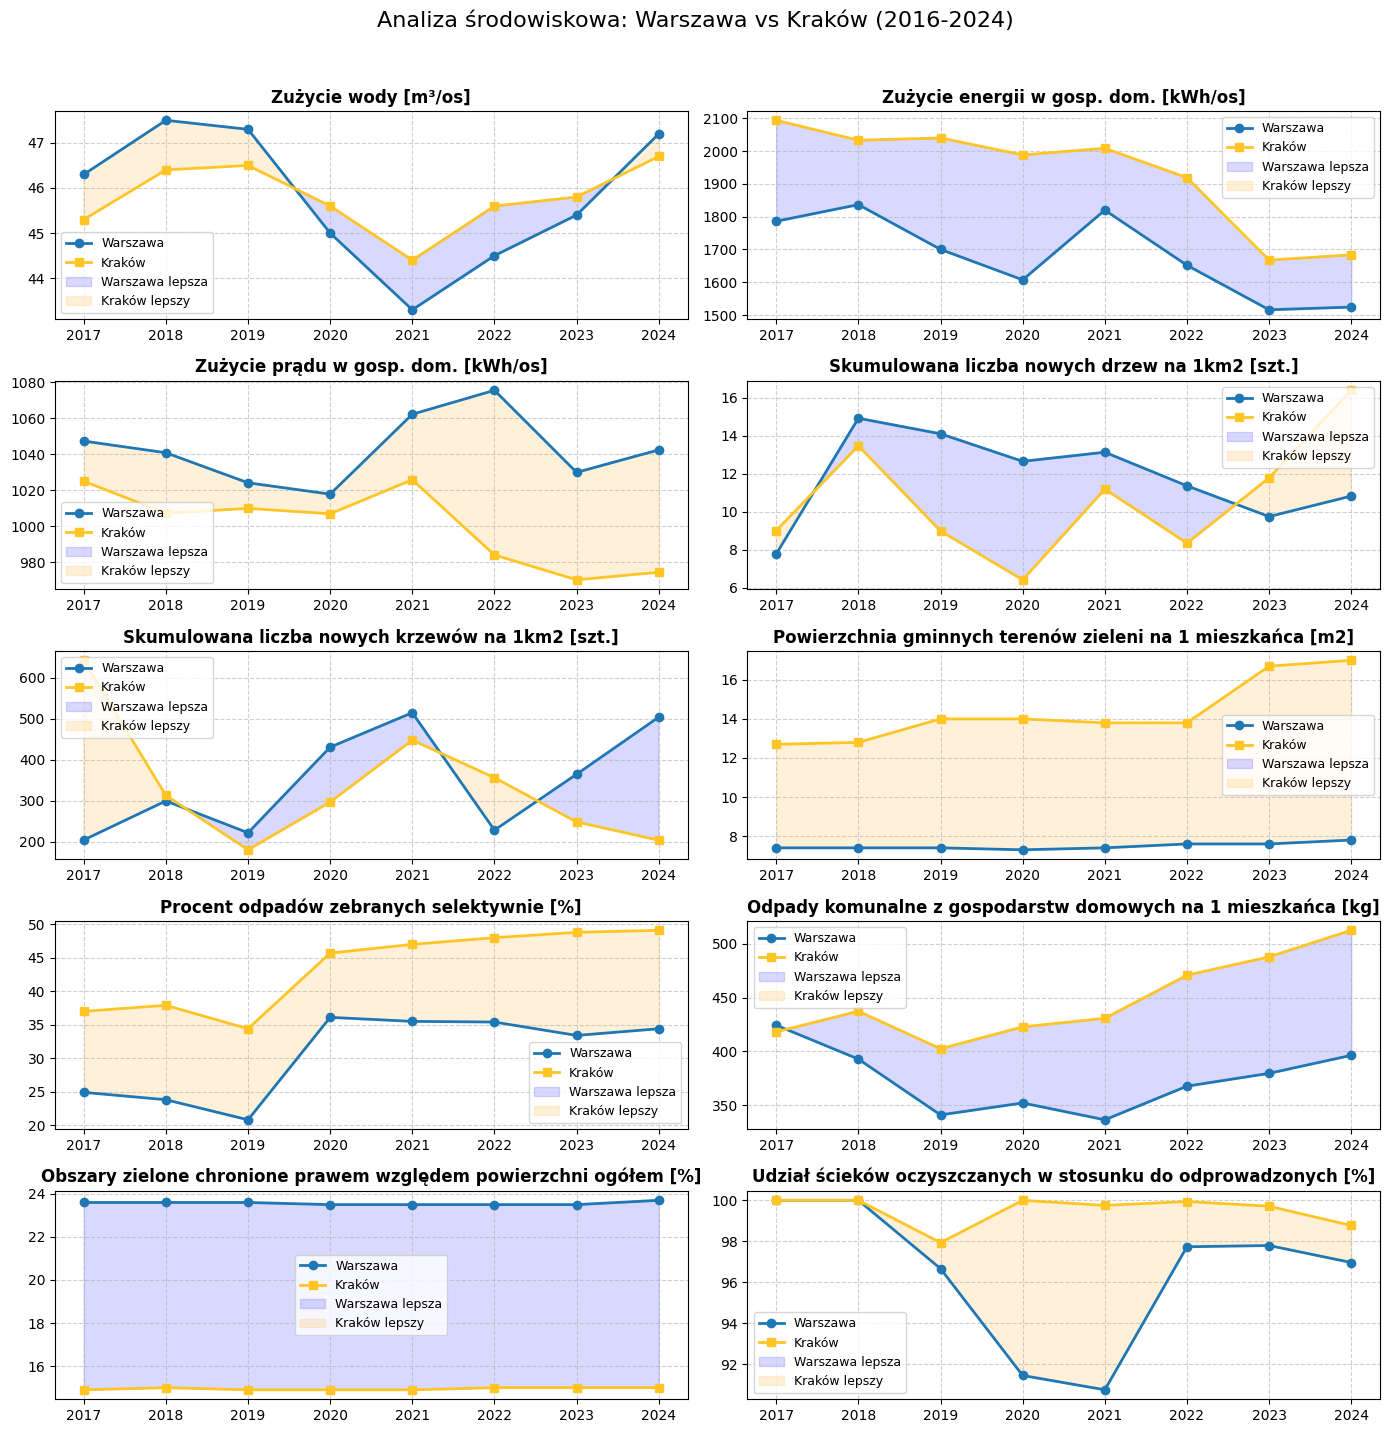

In [17]:
fig, axes = plt.subplots(5, 2, figsize=(14, 14))
axes = axes.flatten()

for i, (name, values) in enumerate(metrics.items()):
    ax = axes[i]
    waw = values['WAW'].values
    years = values['WAW'].index
    krk = values['KRK'].values

    
    ax.plot(years, waw, label='Warszawa', color='#1f77b4', marker='o', linewidth=2)
    ax.plot(years, krk, label='Kraków', color="#ffc527", marker='s', linewidth=2)
    
    if values["Positive"]:
        ax.fill_between(years, waw, krk, where=(np.array(waw) >= np.array(krk)), 
                        color='blue', alpha=0.15, interpolate=True, label='Warszawa lepsza')
        ax.fill_between(years, waw, krk, where=(np.array(waw) < np.array(krk)), 
                        color='orange', alpha=0.15, interpolate=True, label='Kraków lepszy')
    else:
        ax.fill_between(years, waw, krk, where=(np.array(waw) <= np.array(krk)), 
                        color='blue', alpha=0.15, interpolate=True, label='Warszawa lepsza')
        ax.fill_between(years, waw, krk, where=(np.array(waw) > np.array(krk)), 
                        color='orange', alpha=0.15, interpolate=True, label='Kraków lepszy')
    
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(fontsize=9)

plt.suptitle('Analiza środowiskowa: Warszawa vs Kraków (2016-2024)', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('img/environmental_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [18]:
import seaborn as sns

ModuleNotFoundError: No module named 'seaborn'

In [ ]:
rows = []
for year in allowed_years:
    for city in ['WAW', 'KRK']:
        row = {'City': city, 'Year': year}
        for metric_name, data in metrics.items():
            row[metric_name] = data[city][year]
        rows.append(row)

df = pd.DataFrame(rows).set_index(['City', 'Year'])

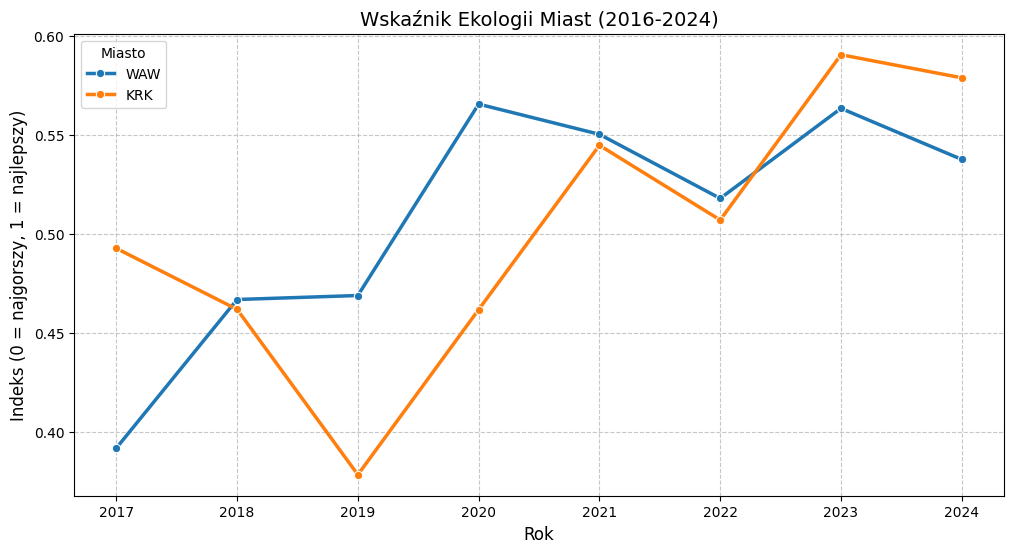

           EcoIndex
City Year          
WAW  2017  0.391883
KRK  2017  0.492792
WAW  2018  0.466960
KRK  2018  0.461976
WAW  2019  0.468978
KRK  2019  0.378443
WAW  2020  0.565671
KRK  2020  0.461861
WAW  2021  0.550412
KRK  2021  0.544859
WAW  2022  0.518035
KRK  2022  0.507120
WAW  2023  0.563511
KRK  2023  0.590619
WAW  2024  0.537716
KRK  2024  0.578959


In [ ]:


# 1. Przygotowanie danych (zamiast negacji, użyjemy logiki odwracania)


# 2. Normalizacja (Min-Max)
# Dla wskaźników 'Positive=True' (im więcej tym lepiej): (x - min) / (max - min)
# Dla wskaźników 'Positive=False' (im mniej tym lepiej): (max - x) / (max - min)
df_norm = pd.DataFrame(index=df.index)

for col in df.columns:
    is_positive = metrics[col].get('Positive', True)
    min_val = df[col].min()
    max_val = df[col].max()
    
    if is_positive:
        df_norm[col] = (df[col] - min_val) / (max_val - min_val)
    else:
        df_norm[col] = (max_val - df[col]) / (max_val - min_val)

# 3. Obliczenie wskaźnika (średnia z kolumn)
# Możesz tu dodać wagi, np. {'Metric': 0.5, ...}
df['EcoIndex'] = df_norm.mean(axis=1)

# 4. Wykres
plt.figure(figsize=(12, 6))
sns.lineplot(data=df.reset_index(), x='Year', y='EcoIndex', hue='City', marker='o', linewidth=2.5)

plt.title('Wskaźnik Ekologii Miast (2016-2024)', fontsize=14)
plt.ylabel('Indeks (0 = najgorszy, 1 = najlepszy)', fontsize=12)
plt.xlabel('Rok', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Miasto')
plt.savefig('img/eco_index_comparison.png', dpi=300)
plt.show()

print(df[['EcoIndex']])